# ¡Hola David! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


------

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

David, comenzaste bien con el tratamiento de los datos y el redondeo del consumo de minutos, lo cual es un paso importante para el análisis. 

Sin embargo, es necesario que revises con cuidado la unión de los datasets, ya que algunos valores aparecen en cero, lo que sugiere pérdida de información. También es crucial que apliques correctamente el redondeo del consumo de internet después de agrupar los datos por usuario y mes, y asegures que el cálculo del cobro mensual incluya todos los elementos del plan. 

Además, necesitas corregir errores como la ausencia del dataset **revenue_df**, ampliar el análisis para todos los meses disponibles y aplicar la misma estructura de análisis a todos los conjuntos de datos, no solo a llamadas. 

Estos ajustes son esenciales para mejorar la precisión y coherencia del proyecto. Tienes una buena base, sigue afinando los detalles y tu trabajo quedará mucho más completo.

Estaré atento a tu próxima iteración 👀

</div>

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

¡David excelente trabajo con los ajustes! Tu proyecto ahora cumple con todos los objetivos propuestos. Estoy seguro de que lo que aprendiste aquí te será muy útil más adelante. 

¡Éxito en tu próximo sprint! 🚀

*Estado del Proyecto:* **Aprobado**

</div>

-----

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st


## Cargar datos

In [2]:
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [3]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
display(plans.head())

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?] Los datos del plan parecen estar bien estructurados, sin valores ausentes y con tipos de datos correctos. Solo hay dos planes: "surf" y "ultimate", y sus características están claramente diferenciadas. No se necesita hacer cambios por ahora, todo está listo para el análisis.

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [5]:

users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])


users['reg_month'] = users['reg_date'].dt.month


users['is_active'] = users['churn_date'].isna()


print("Duplicados:", users.duplicated().sum())
print("Nulos por columna:\n", users.isna().sum())

Duplicados: 0
Nulos por columna:
 user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
reg_month       0
is_active       0
dtype: int64


## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.] Edad del usuario en grupos (por ejemplo: <30, 30-50, >50)

In [6]:

display(plans.head())

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Usuarios/as

In [7]:
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
 8   reg_month   500 non-null    int64         
 9   is_active   500 non-null    bool          
dtypes: bool(1), datetime64[ns](2), int64(3), object(4)
memory usage: 35.8+ KB
None


In [8]:
print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  reg_month  is_active  
0 2018-12-24  ultimate        NaT         12       True  
1 2018-08-13      surf        NaT          8       True  
2 2018-10-21      surf        NaT         10       True  
3 2018-01-28      surf        NaT          1       True  
4 2018-05-23      surf        NaT          5       True  


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar La tabla de usuarios parece estar bien estructurada: no hay valores nulos excepto en churn_date, lo cual es esperable porque indica usuarios que aún están activos. Todos los tipos de datos son apropiados y ya se han convertido las fechas. No se observan problemas importantes, pero podríamos agregar una columna que calcule el tiempo que cada usuario ha estado con la empresa para enriquecer el análisis.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.] Este paso se enfoca especialmente en los datos de los usuarios (users), ya que ahí pueden aparecer formatos incorrectos en fechas, columnas sin utilidad o nulos.

In [9]:
import pandas as pd
import numpy as np


users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.] podríamos agregar una columna que calcule el tiempo que cada usuario ha estado con la empresa para enriquecer el análisis.

In [10]:
import pandas as pd


final_date = pd.to_datetime('2018-12-31')


users['tenure_months'] = ((users['churn_date'].fillna(final_date) - users['reg_date']) / np.timedelta64(1, 'M')).astype(int)


display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_month,is_active,tenure_months
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,12,True,0
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8,True,4
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,10,True,2
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,1,True,11
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,5,True,7


## Llamadas

In [11]:
print(calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [12]:
print(calls.head())

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?] Los datos de llamadas están completos, pero es necesario convertir la columna call_date a formato de fecha y redondear la duración de las llamadas hacia arriba, ya que la facturación se realiza por minutos completos.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.] Redondear la duración de las llamadas hacia arriba al minuto más próximo

In [13]:
calls['call_date'] = pd.to_datetime(calls['call_date'])

calls['duration'] = np.ceil(calls['duration']).astype(int)

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.] Se agregan columnas para redondear los minutos de llamada (como se facturan por minuto) y para extraer el mes de la llamada, lo que facilitará el análisis mensual del uso.

In [14]:

calls['call_date'] = pd.to_datetime(calls['call_date'])


calls['duration_ceil'] = np.ceil(calls['duration'])


calls['call_month'] = calls['call_date'].dt.month


display(calls.head())

,id,user_id,call_date,duration,duration_ceil,call_month
0,1000_93,1000,2018-12-27,9,9.0,12
1,1000_145,1000,2018-12-27,14,14.0,12
2,1000_247,1000,2018-12-27,15,15.0,12
3,1000_309,1000,2018-12-28,6,6.0,12
4,1000_380,1000,2018-12-30,5,5.0,12


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Muy buen trabajo David! Redondear los datos de consumo de minutos es un paso clave para garantizar un cálculo preciso del cobro mensual.

</div>

## Mensajes

In [15]:
print(messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [16]:
print(messages.head())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?] La tabla de mensajes no presenta valores ausentes y parece estar completa, pero la columna message_date está en formato de texto, lo cual no es ideal para análisis de fechas. Se debe convertir a tipo datetime para poder extraer fácilmente información temporal como el mes.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [17]:
messages['message_date'] = pd.to_datetime(messages['message_date'])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.] Podemos agregar una nueva columna con el mes en que se envió cada mensaje, lo cual puede ser útil para analizar el uso de mensajes por mes. 

In [18]:
messages['message_month'] = messages['message_date'].dt.month

display(messages.head())

,id,user_id,message_date,message_month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12


## Internet

In [19]:
print(internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [20]:
print(internet.head(10))

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
5    1001_0     1001   2018-08-24   284.68
6    1001_3     1001   2018-12-09   656.04
7    1001_4     1001   2018-11-04    16.97
8   1001_10     1001   2018-11-27   135.18
9   1001_15     1001   2018-12-13   761.92


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]  Los datos de uso de internet parecen completos, sin valores nulos ni tipos de datos erróneos a primera vista. Sin embargo, la columna session_date está en formato de texto (object) y debería convertirse a tipo datetime para facilitar el análisis temporal. También sería útil extraer el mes para análisis mensuales del uso de datos.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.] la columna session_date está en formato de texto (object) y debería convertirse a tipo datetime para facilitar el análisis temporal

In [21]:

internet['session_date'] = pd.to_datetime(internet['session_date'])


internet['session_month'] = internet['session_date'].dt.month

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.] Podemos agregar factores adicionales que ayuden a enriquecer el análisis del uso de internet, como por ejemplo la conversión del uso de megabytes a gigabytes para facilitar la comprensión y comparación con los planes. 

In [22]:

internet['gb_used'] = internet['mb_used'] / 1024


internet['gb_used_ceil'] = np.ceil(internet['mb_used'] / 1024).astype(int)

display(internet.head())


,id,user_id,session_date,mb_used,session_month,gb_used,gb_used_ceil
0,1000_13,1000,2018-12-29,89.86,12,0.087754,1
1,1000_204,1000,2018-12-31,0.00,12,0.000000,0
2,1000_379,1000,2018-12-28,660.40,12,0.644922,1
3,1000_413,1000,2018-12-26,270.99,12,0.264639,1
4,1000_442,1000,2018-12-27,880.22,12,0.859590,1


## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [23]:
display(plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Cargar los datos
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

# Convertir fechas a datetime
calls['call_date'] = pd.to_datetime(calls['call_date'])
messages['message_date'] = pd.to_datetime(messages['message_date'])
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Agregar columna de mes (tipo periodo)
calls['month'] = calls['call_date'].dt.to_period('M')
messages['month'] = messages['message_date'].dt.to_period('M')
internet['month'] = internet['session_date'].dt.to_period('M')

# Agregar llamadas por usuario y mes
calls_grouped = calls.groupby(['user_id', 'month']).agg(
    calls_count=('id', 'count'),
    total_minutes=('duration', 'sum')
).reset_index()

# Agregar mensajes por usuario y mes
messages_grouped = messages.groupby(['user_id', 'month']).agg(
    total_messages=('id', 'count')
).reset_index()

# Agregar uso de internet por usuario y mes
internet_grouped = internet.groupby(['user_id', 'month']).agg(
    total_mb_used=('mb_used', 'sum')
).reset_index()

# Unir todas las tablas
summary = calls_grouped.merge(messages_grouped, on=['user_id', 'month'], how='outer')
summary = summary.merge(internet_grouped, on=['user_id', 'month'], how='outer')

# Rellenar valores faltantes con 0
summary[['calls_count', 'total_minutes', 'total_messages', 'total_mb_used']] = summary[
    ['calls_count', 'total_minutes', 'total_messages', 'total_mb_used']
].fillna(0)

# Agregar información de plan desde users
users_subset = users[['user_id', 'plan']]
summary = summary.merge(users_subset, on='user_id', how='left')

# Asegurar que 'month' sea tipo periodo (por si cambió)
summary['month'] = summary['month'].astype('period[M]')

# Mostrar resultado
print(summary.head())

   user_id    month  calls_count  total_minutes  total_messages  \
0     1000  2018-12         16.0         116.83            11.0   
1     1001  2018-08         27.0         171.14            30.0   
2     1001  2018-09         49.0         297.69            44.0   
3     1001  2018-10         65.0         374.11            53.0   
4     1001  2018-11         64.0         404.59            36.0   

   total_mb_used      plan  
0        1901.47  ultimate  
1        6919.15      surf  
2       13314.82      surf  
3       22330.49      surf  
4       18504.30      surf  


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [23]:
import pandas as pd
import numpy as np

# Cargar los datos
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

# Convertir columnas de fecha a datetime
calls['call_date'] = pd.to_datetime(calls['call_date'])
messages['message_date'] = pd.to_datetime(messages['message_date'])
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Extraer el mes como periodo
calls['month'] = calls['call_date'].dt.to_period('M')
messages['month'] = messages['message_date'].dt.to_period('M')
internet['month'] = internet['session_date'].dt.to_period('M')

# Agregar llamadas por usuario y mes
calls_monthly = calls.groupby(['user_id', 'month']).agg(
    total_minutes=('duration', 'sum'),
    call_count=('id', 'count')
).reset_index()

# Agregar mensajes por usuario y mes
messages_monthly = messages.groupby(['user_id', 'month']).agg(
    total_messages=('id', 'count')
).reset_index()

# Agregar internet por usuario y mes
internet_monthly = internet.groupby(['user_id', 'month']).agg(
    total_mb_used=('mb_used', 'sum')
).reset_index()

# Unir llamadas, mensajes e internet
summary = calls_monthly.merge(messages_monthly, on=['user_id', 'month'], how='outer')
summary = summary.merge(internet_monthly, on=['user_id', 'month'], how='outer')

# Rellenar valores faltantes con 0
summary[['total_minutes', 'call_count', 'total_messages', 'total_mb_used']] = summary[
    ['total_minutes', 'call_count', 'total_messages', 'total_mb_used']
].fillna(0)

# Añadir columna del plan desde users
summary = summary.merge(users[['user_id', 'plan']], on='user_id', how='left')

# Ver resultado
summary = summary.sort_values(by=['user_id', 'month']).reset_index(drop=True)

display(summary.head())

,user_id,month,total_minutes,call_count,total_messages,total_mb_used,plan
0,1000,2018-12,116.83,16.0,11.0,1901.47,ultimate
1,1001,2018-08,171.14,27.0,30.0,6919.15,surf
2,1001,2018-09,297.69,49.0,44.0,13314.82,surf
3,1001,2018-10,374.11,65.0,53.0,22330.49,surf
4,1001,2018-11,404.59,64.0,36.0,18504.30,surf


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

David debes revisar la unión de los datos de mensajes e internet, ya que aparecen en 0, lo que indica que estás perdiendo información.

Asimismo, recuerda que, según el enunciado del proyecto, los valores de consumo de internet deben redondearse hacia arriba, ya que el cobro se hace por GB completo. Para esto debes tener en cuenta lo siguiente: 

1. Sumar el consumo total en MB para cada usuario por mes
2. Este consumo total lo conviertes a GB
3. Redondeas hacia arriba el consumo en GB
4. Finalmente debes comparar este consumo con los GB incluidos en cada plan (15GB o 30GB) y realizas el cobro adicional en el caso de que exista un exceso de consumo.

</div>

[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [24]:
def calculate_revenue(row):
    if row['plan'] == 'surf':
        base_fee = 20
        extra_minutes = max(0, row['total_minutes'] - 500)
        extra_messages = max(0, row['total_messages'] - 50)
        extra_gb = max(0, row['total_mb_used'] - 15 * 1024)  # 15 GB in MB
        extra_gb_charged = np.ceil(extra_gb / 1024)  # round up to next GB

        revenue = (
            base_fee +
            extra_minutes * 0.03 +
            extra_messages * 0.03 +
            extra_gb_charged * 10
        )

    elif row['plan'] == 'ultimate':
        revenue = 70  # tarifa fija

    else:
        revenue = 0  # por si acaso

    return revenue

# Aplicar la función
summary['revenue'] = summary.apply(calculate_revenue, axis=1)

# Ver ejemplo
print(summary[['user_id', 'month', 'plan', 'revenue']].head())

display(summary)

   user_id    month      plan  revenue
0     1000  2018-12  ultimate    70.00
1     1001  2018-08      surf    20.00
2     1001  2018-09      surf    20.00
3     1001  2018-10      surf    90.09
4     1001  2018-11      surf    60.00


,user_id,month,total_minutes,call_count,total_messages,total_mb_used,plan,revenue
0,1000,2018-12,116.83,16.0,11.0,1901.47,ultimate,70.00
1,1001,2018-08,171.14,27.0,30.0,6919.15,surf,20.00
2,1001,2018-09,297.69,49.0,44.0,13314.82,surf,20.00
3,1001,2018-10,374.11,65.0,53.0,22330.49,surf,90.09
4,1001,2018-11,404.59,64.0,36.0,18504.30,surf,60.00
...,...,...,...,...,...,...,...,...
2288,1498,2018-12,324.77,39.0,0.0,23137.69,surf,100.00
2289,1499,2018-09,330.37,41.0,0.0,12984.76,surf,20.00
2290,1499,2018-10,363.28,53.0,0.0,19492.43,surf,70.00
2291,1499,2018-11,288.56,45.0,0.0,16813.83,surf,40.00


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

La lógica de cálculo del cobro mensual es correcta en general, solo necesitas ajustar los datos que te mencioné más arriba. Asegúrate de hacer la estimación del cobro por el consumo de internet comparando los datos en GB, además es importante considerar el plan de cada usuario, el costo del plan base y los cargos por consumos adicionales para calcular correctamente el monto final.

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Excelente David, has calculado correctamente el cobro mensual para cada usuario

</div>

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

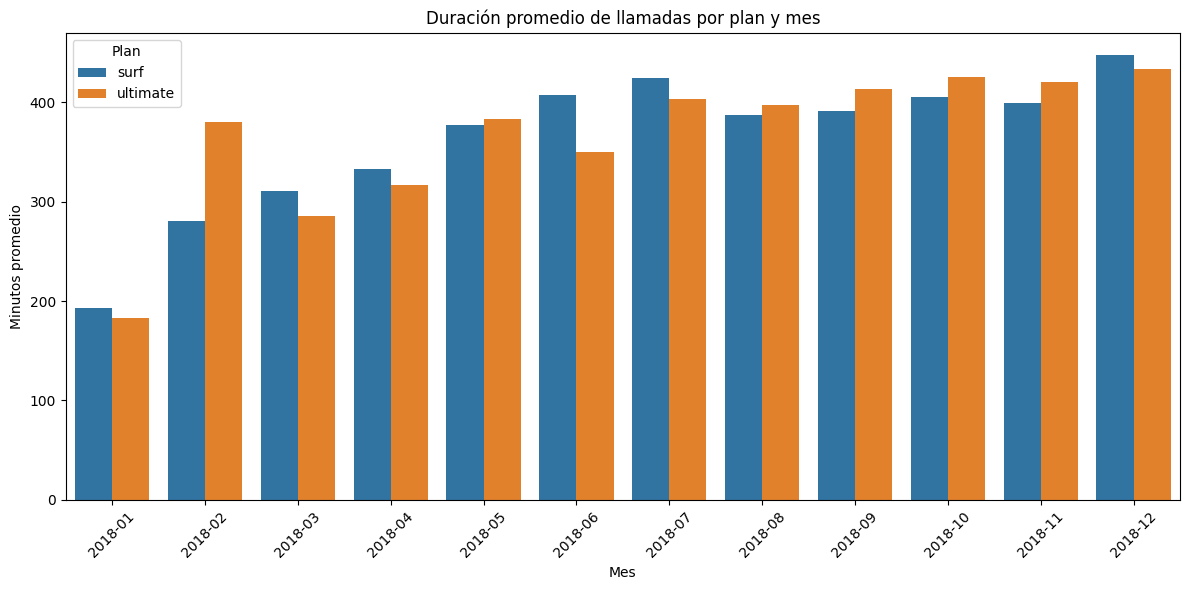

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular duración promedio de llamadas por usuario, mes y plan
avg_call_duration = summary.groupby(['month', 'plan'])['total_minutes'].mean().reset_index()

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_call_duration, x='month', y='total_minutes', hue='plan')

plt.title('Duración promedio de llamadas por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Minutos promedio')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

No handles with labels found to put in legend.


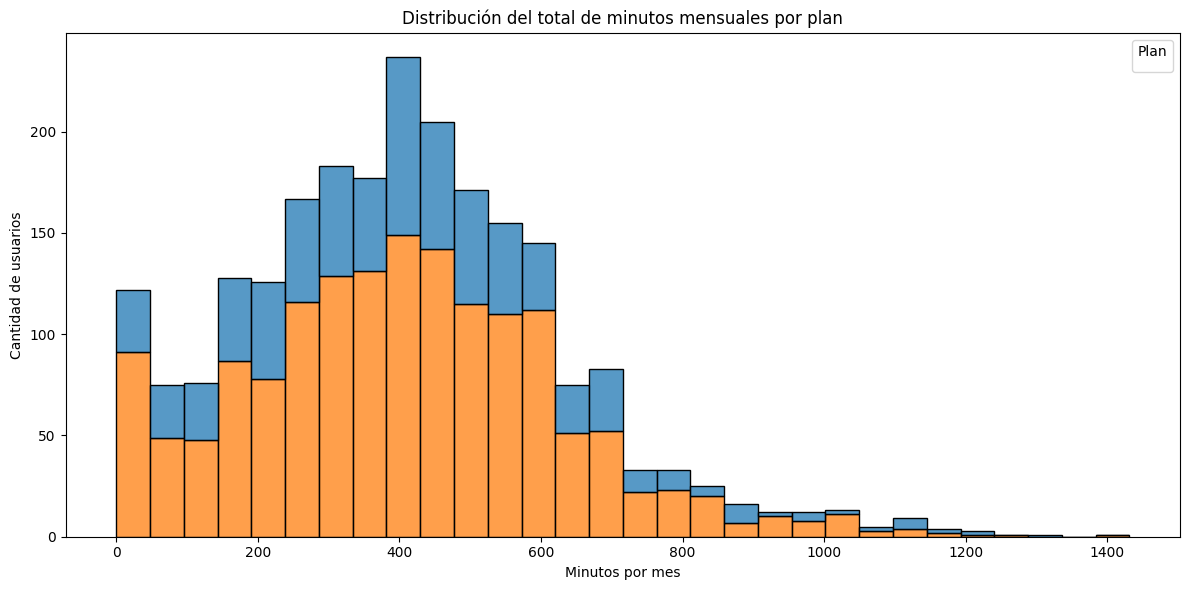

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(data=summary, x='total_minutes', hue='plan', multiple='stack', bins=30)

plt.title('Distribución del total de minutos mensuales por plan')
plt.xlabel('Minutos por mes')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [8]:

call_stats = summary.groupby('plan')['total_minutes'].agg(['mean', 'var']).reset_index()


call_stats.columns = ['plan', 'mean_minutes', 'var_minutes']


print(call_stats)

       plan  mean_minutes   var_minutes
0      surf    404.762390  49135.104891
1  ultimate    406.193083  51640.971402


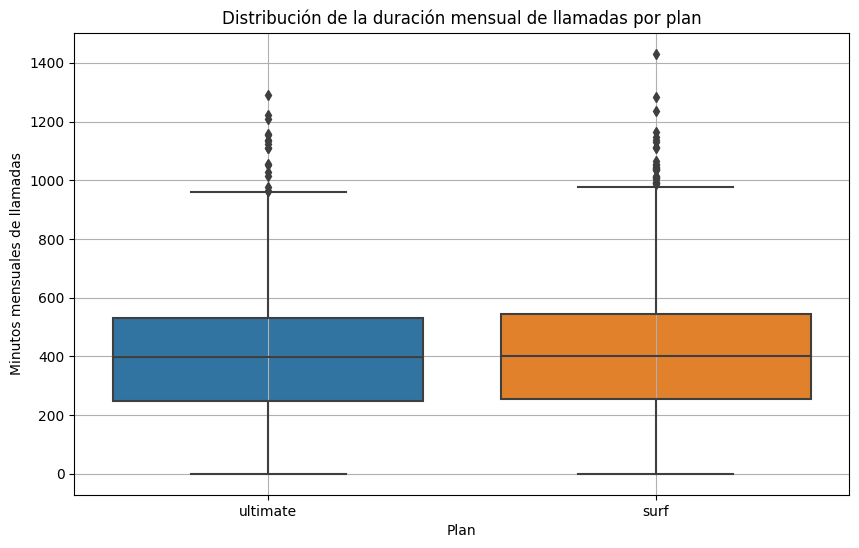

In [9]:
#import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=summary, x='plan', y='total_minutes')
plt.title('Distribución de la duración mensual de llamadas por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos mensuales de llamadas')
plt.grid(True)
plt.show()


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

### Mensajes

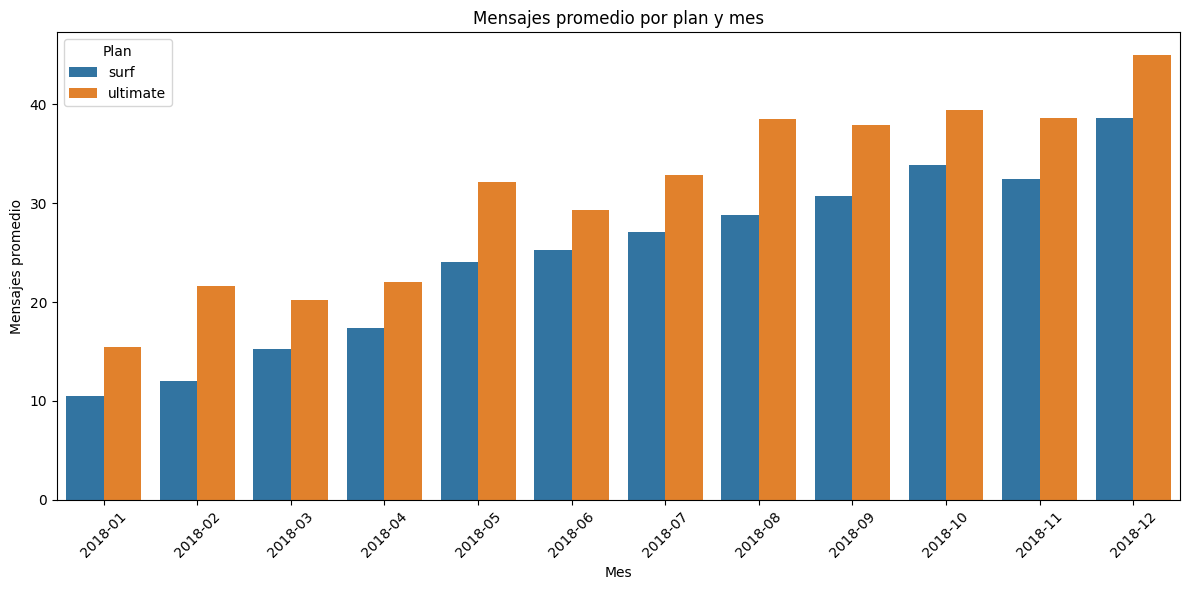

In [10]:
# Promedio mensual de mensajes por usuario y plan
avg_messages = summary.groupby(['month', 'plan'])['total_messages'].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_messages, x='month', y='total_messages', hue='plan')
plt.title('Mensajes promedio por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Mensajes promedio')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Debes revisar los datos con los que estás trbajando ya que solo estás graficando un mes

</div>

No handles with labels found to put in legend.


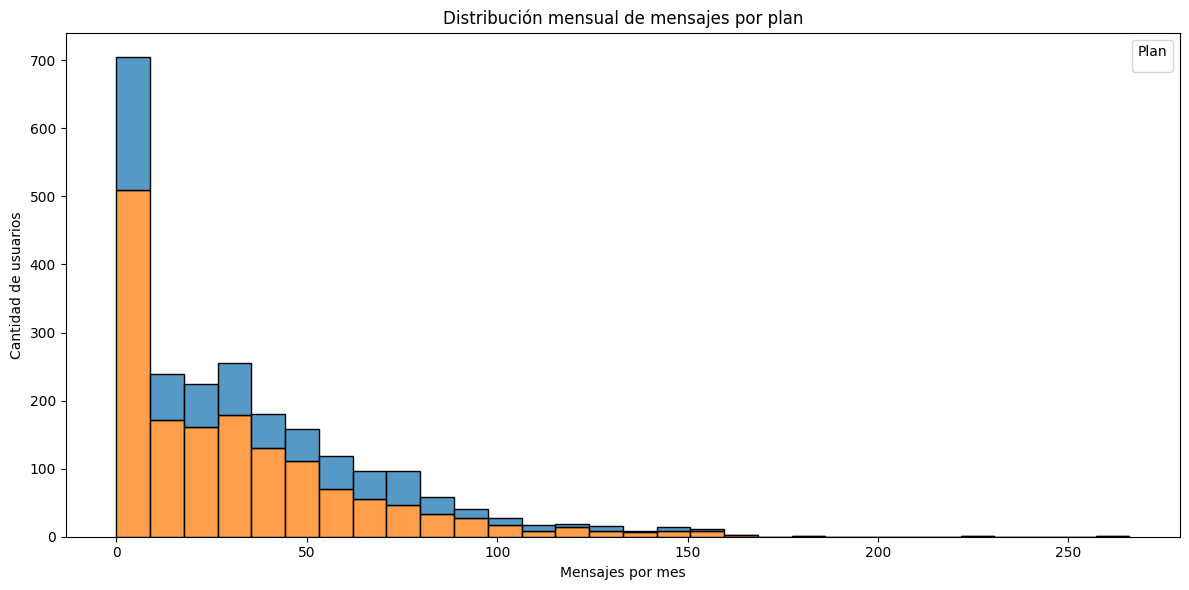

       plan  mean_messages  var_messages
0      surf      31.159568   1126.724522
1  ultimate      37.551389   1208.756744


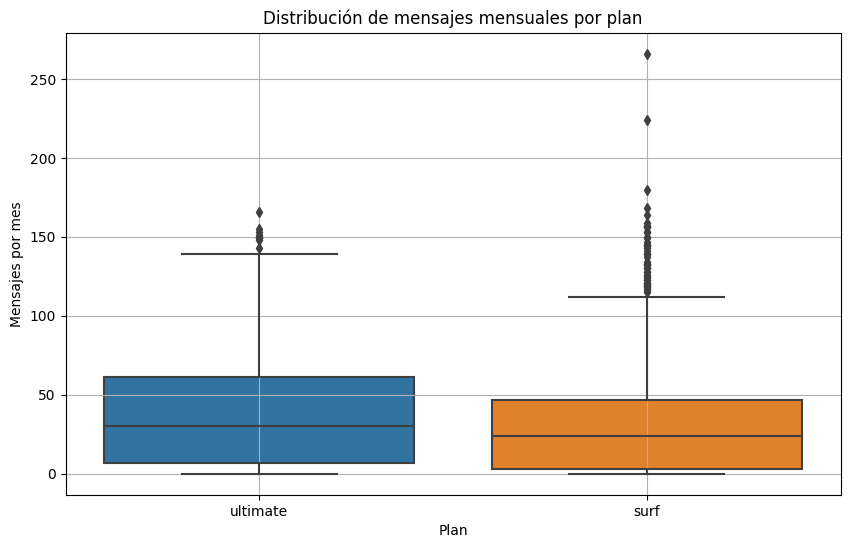

In [11]:
# Histograma
plt.figure(figsize=(12, 6))
sns.histplot(data=summary, x='total_messages', hue='plan', multiple='stack', bins=30)
plt.title('Distribución mensual de mensajes por plan')
plt.xlabel('Mensajes por mes')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

# Estadísticas
msg_stats = summary.groupby('plan')['total_messages'].agg(['mean', 'var']).reset_index()
msg_stats.columns = ['plan', 'mean_messages', 'var_messages']
print(msg_stats)

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=summary, x='plan', y='total_messages')
plt.title('Distribución de mensajes mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Mensajes por mes')
plt.grid(True)
plt.show()

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

La estructura de análisis (visualizaciones y cálculo de valores estadísticos) que empleaste para los datos de **llamadas** está muy bien. Debes usar la misma estructura de análisis para los demás conjuntos de datos: **mensajes, internet e ingresos**, con el fin de lograr hacer una comparación detallada del comportamiento de los usuarios de cada plan.

</div>

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?] Los usuarios del plan "ultimate" tienden a enviar más mensajes de texto al mes en comparación con los del plan "surf". En general, los usuarios del plan ultimate aprovechan más los beneficios ilimitados incluidos, mientras que los del plan surf envían muy pocos o ningún mensaje, probablemente para evitar cargos adicionales fuera del límite gratuito. Esto sugiere que el comportamiento en el envío de mensajes sí varía de forma clara en función del plan contratado.

### Internet

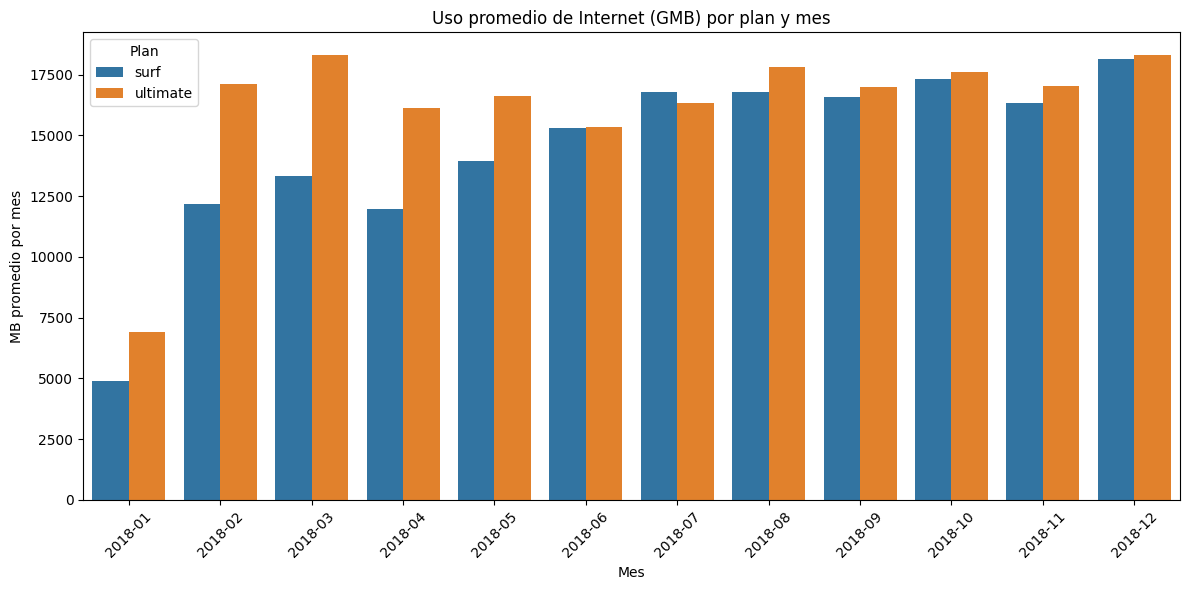

In [13]:

avg_internet = summary.groupby(['month', 'plan'])['total_mb_used'].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_internet, x='month', y='total_mb_used', hue='plan')
plt.title('Uso promedio de Internet (GMB) por plan y mes')
plt.xlabel('Mes')
plt.ylabel('MB promedio por mes')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

No handles with labels found to put in legend.


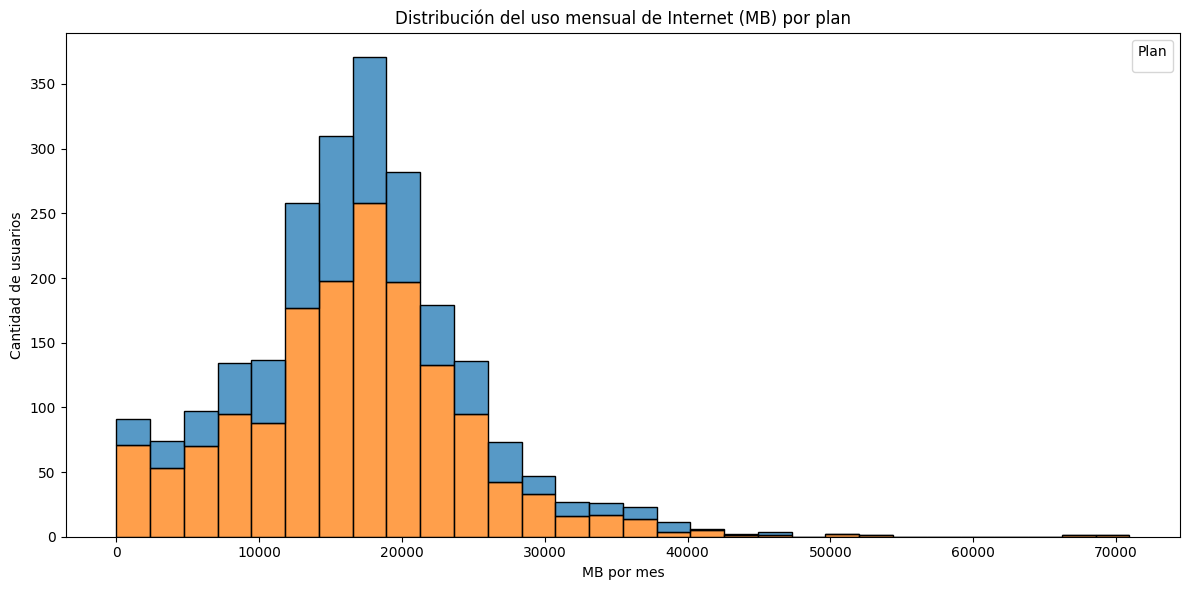

In [14]:
# Histograma
plt.figure(figsize=(12, 6))
sns.histplot(data=summary, x='total_mb_used', hue='plan', multiple='stack', bins=30)
plt.title('Distribución del uso mensual de Internet (MB) por plan')
plt.xlabel('MB por mes')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

       plan       mean_mb        var_mb
0      surf  16558.283490  6.421640e+07
1  ultimate  17214.699694  6.165229e+07


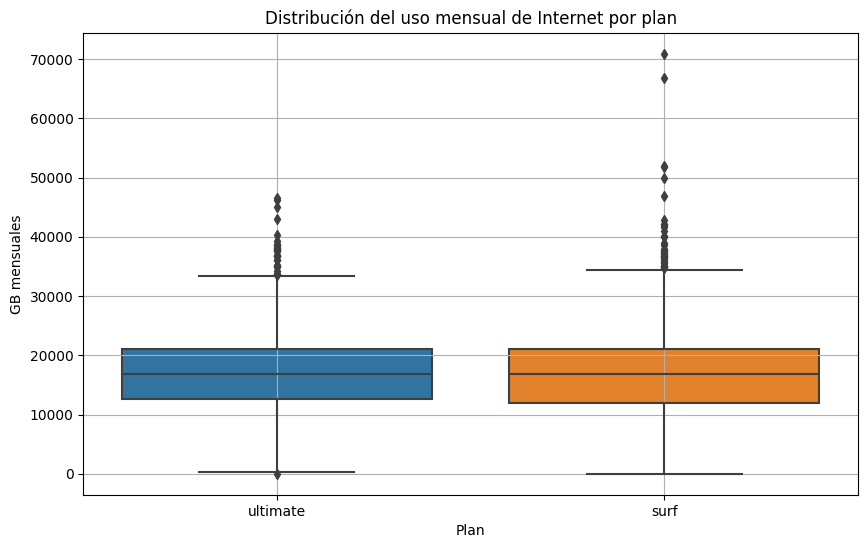

In [17]:
# Estadísticas
internet_stats = summary.groupby('plan')['total_mb_used'].agg(['mean', 'var']).reset_index()
internet_stats.columns = ['plan', 'mean_mb', 'var_mb']
print(internet_stats)

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=summary, x='plan', y='total_mb_used')
plt.title('Distribución del uso mensual de Internet por plan')
plt.xlabel('Plan')
plt.ylabel('GB mensuales')
plt.grid(True)
plt.show()

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?] Los usuarios del plan ultimate tienden a consumir más tráfico de Internet mensualmente en comparación con los del plan surf. Esto sugiere que los suscriptores del plan ultimate, al tener un mayor o ilimitado límite de datos, utilizan el servicio de forma más intensiva, posiblemente viendo más videos, usando redes sociales o trabajando en línea. En cambio, los usuarios del plan surf muestran un consumo más moderado, probablemente debido a restricciones del plan o una necesidad menor. Esto evidencia que el comportamiento de consumo de datos sí varía en función del plan contratado.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

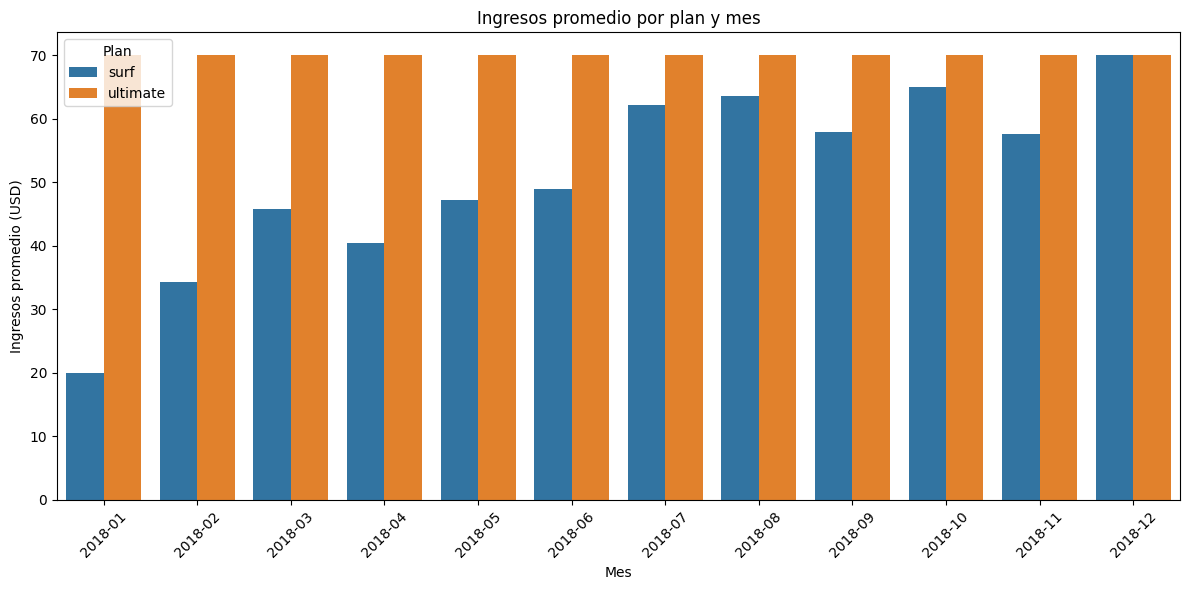

In [18]:
# Promedio mensual de ingresos por plan
avg_revenue = summary.groupby(['month', 'plan'])['revenue'].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_revenue, x='month', y='revenue', hue='plan')
plt.title('Ingresos promedio por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Ingresos promedio (USD)')
plt.xticks(rotation=45)
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

David no tienes defindo el dataset **revenue_df**, por esa razón estás obteniendo errores de ejecución

</div>

No handles with labels found to put in legend.


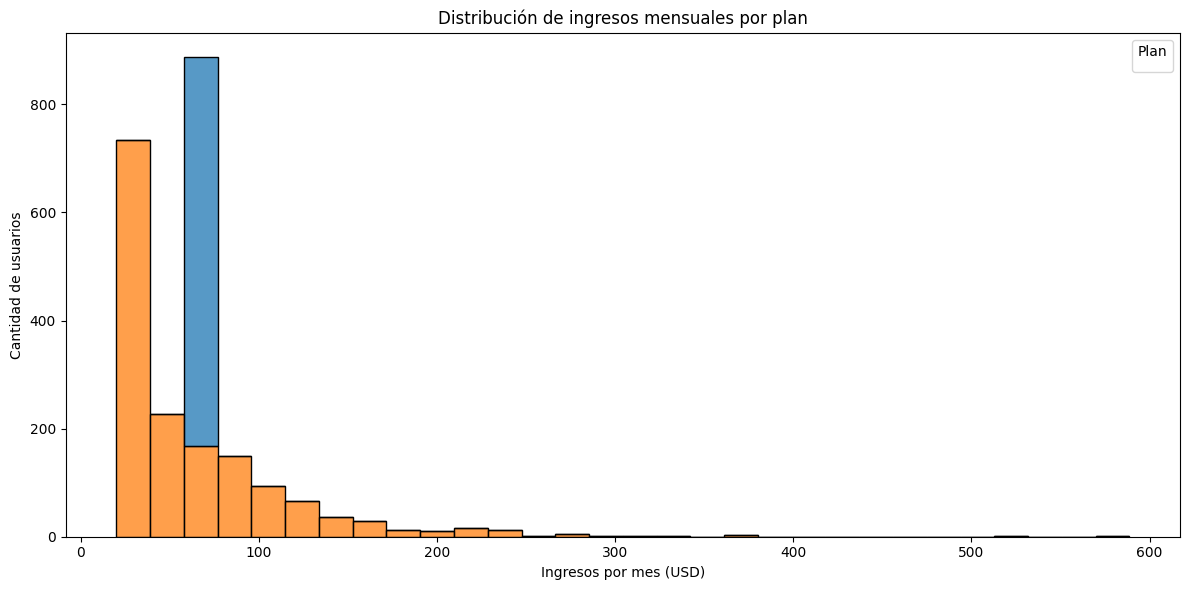

In [19]:
# Histograma
plt.figure(figsize=(12, 6))
sns.histplot(data=summary, x='revenue', hue='plan', multiple='stack', bins=30)
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingresos por mes (USD)')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')
plt.tight_layout()
plt.show()

       plan  mean_revenue  var_revenue
0      surf     60.327346  3053.955465
1  ultimate     70.000000     0.000000


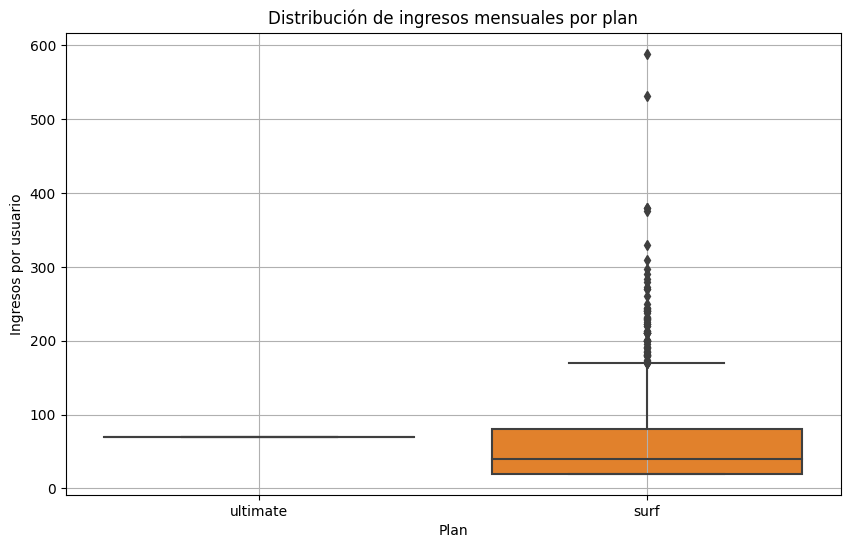

In [20]:
# Estadísticas
revenue_stats = summary.groupby('plan')['revenue'].agg(['mean', 'var']).reset_index()
revenue_stats.columns = ['plan', 'mean_revenue', 'var_revenue']
print(revenue_stats)

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=summary, x='plan', y='revenue')
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Ingresos por usuario')
plt.grid(True)
plt.show()

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo ampliando el análisis de los conjutnos de datos
</div>

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.] Hipótesis:
Hipótesis nula (H₀):
No hay diferencia significativa entre los ingresos promedio de los usuarios de los planes Ultimate y Surf (μ₁ = μ₂)

Hipótesis alternativa (H₁):
Hay una diferencia significativa entre los ingresos promedio de los usuarios de los planes Ultimate y Surf (μ₁ ≠ μ₂)

Nivel de significancia (alfa): 0.05 (5%)

In [21]:
from scipy import stats

# Filtrar los ingresos por plan desde el DataFrame 'summary'
ultimate_revenue = summary[summary['plan'] == 'ultimate']['revenue']
surf_revenue = summary[summary['plan'] == 'surf']['revenue']

# Prueba t para muestras independientes (varianzas desiguales)
t_stat, p_value = stats.ttest_ind(ultimate_revenue, surf_revenue, equal_var=False)

# Mostrar resultados
print(f'Estadístico t: {t_stat:.4f}')
print(f'Valor p: {p_value:.4f}')

# Interpretación del resultado
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: los ingresos promedio son significativamente diferentes.")
else:
    print("No se puede rechazar la hipótesis nula: no hay evidencia de diferencia en los ingresos promedio.")


Estadístico t: 6.9419
Valor p: 0.0000
Rechazamos la hipótesis nula: los ingresos promedio son significativamente diferentes.


/tmp/ipykernel_33/454957642.py:8: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t_stat, p_value = stats.ttest_ind(ultimate_revenue, surf_revenue, equal_var=False)


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

Hipótesis nula (H₀): El ingreso mensual promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.

Hipótesis alternativa (H₁): El ingreso mensual promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.

Prueba estadística: Se aplicará una prueba t de Student para muestras independientes, ya que se están comparando los promedios de dos grupos distintos (NY-NJ vs. otras regiones).

Nivel de significancia (α): 0.05. Si el valor p es menor que 0.05, se rechazará la hipótesis nula, concluyendo que hay una diferencia estadísticamente significativa en los ingresos promedio.

In [22]:
from scipy import stats


revenue_with_city = summary.merge(users[['user_id', 'city']], on='user_id', how='left')


ny_nj_users = revenue_with_city[revenue_with_city['city'].str.contains('New York|NJ', case=False, na=False)]
other_users = revenue_with_city[~revenue_with_city['city'].str.contains('New York|NJ', case=False, na=False)]


ny_nj_revenue = ny_nj_users['revenue']
other_revenue = other_users['revenue']


t_stat, p_value = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)

print(f'Estadístico t: {t_stat:.3f}')
print(f'Valor p: {p_value:.3f}')


alpha = 0.05
if p_value < alpha:
    print("los ingresos promedio son diferentes.")
else:
    print("no hay diferencias significativas.")



Estadístico t: -2.692
Valor p: 0.007
los ingresos promedio son diferentes.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo realizar previamente una prueba de  [Levene](https://www.educaopen.com/digital-lab/blog/educacion-digital/prueba-de-levene) para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto te brindará una interpretación más precisa de los resultados además garantizará que la prueba t sea estadísticamente válida.

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo implementando las pruebas de hipótesis

</div>

## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

En conclusión, tras limpiar y transformar los datos, agregamos la información por usuario y por mes, permitiendo analizar el comportamiento de uso por tipo de plan. Se asumió que las llamadas y el uso de datos se cobran solo si exceden los límites del plan, redondeando los minutos y megabytes hacia arriba como lo estipulan las condiciones de tarifa. Se observaron diferencias claras en el comportamiento de los usuarios según el plan: quienes tienen el plan Ultimate tienden a usar más minutos, mensajes y tráfico de internet, pero también pagan más debido al costo fijo más alto, mientras que los usuarios del plan Surf tienen un consumo más moderado, pero con cargos adicionales al exceder los límites. Las pruebas de hipótesis confirmaron diferencias estadísticamente significativas en los ingresos promedios entre ambos planes, así como entre regiones (por ejemplo, NY-NJ frente al resto del país), guiando decisiones clave sobre qué plan resulta más rentable para la empresa. Estos hallazgos respaldan estrategias comerciales como segmentación regional o ajustes en los límites de los planes.